In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import tensorflow as tf

In [2]:
today = datetime.date.today()
date = today.strftime("%B%d")
date

'August17'

Load the tensorboard log files into pandas dataframe

In [3]:
# Gather data
data = []
logs = glob.glob(rf".\logs\wheeled_random_Aug11\*\*")
for log in logs:
    if "events.out.tfevents" in log:
        experiment_info = log.split('\\')[-2].split('_')
        algorithm = experiment_info[0]
        st = experiment_info[1]
        # print(log)
        print(log.split('\\'))
        print(experiment_info)
        
        for e in tf.compat.v1.train.summary_iterator(log):
            for v in e.summary.value:
                if v.tag == 'rollout/ep_rew_mean':
                    data.append({
                        'algorithm': algorithm,
                        'set': st,
                        'step': e.step,
                        'reward': v.simple_value
                    })
    else:
        print(f"Not a tensorflow log file, file: {log}")
df = pd.DataFrame(data)
df.to_csv(rf"results\wheeled_random_raw_{date}.csv")
df

['.', 'logs', 'wheeled_random_Aug11', 'A2C_env1', 'events.out.tfevents.1754943050.gpu1.2210057.0']
['A2C', 'env1']

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
Not a tensorflow log file, file: .\logs\wheeled_random_Aug11\A2C_env1\log.txt
Not a tensorflow log file, file: .\logs\wheeled_random_Aug11\A2C_env1\progress.csv
Not a tensorflow log file, file: .\logs\wheeled_random_Aug11\A2C_env1\progress.json
['.', 'logs', 'wheeled_random_Aug11', 'A2C_env2', 'events.out.tfevents.1754949178.gpu1.2210057.1']
['A2C', 'env2']
Not a tensorflow log file, file: .\logs\wheeled_random_Aug11\A2C_env2\log.txt
Not a tensorflow log file, file: .\logs\wheeled_random_Aug11\A2C_env2\progress.csv
Not a tensorflow log file, file: .\logs\wheeled_random_Aug11\A2C_env2\progress.json
['.', 'logs', 'wheeled_random_Aug11', 'A2C_env3', 'events.out.tfevents.1754955966.gpu1.2210057.2']
['A2C', 'env3']
Not a tensorflow log file, file: .\logs\wheeled_random_Aug11\A2C_env3\log.txt
N

,algorithm,set,step,reward
0,A2C,env1,8000,-85131.093750
1,A2C,env1,10000,-78183.617188
2,A2C,env1,16000,-70567.500000
3,A2C,env1,20000,-63961.718750
4,A2C,env1,24000,-58372.882812
...,...,...,...,...
26320,TRPO,env8,1949696,-24123.142578
26321,TRPO,env8,1966080,-22194.833984
26322,TRPO,env8,1982464,-17839.132812
26323,TRPO,env8,1998848,-17984.982422


In [4]:
df['algorithm'].unique()

array(['A2C', 'ARS', 'CrossQ', 'PPO', 'TQC', 'TRPO'], dtype=object)

In [5]:
# Scaling the rewards for visualization
df['reward_scaled'] = df['reward'] / 1000000
df['reward_scaled'] = df['reward_scaled'].clip(lower=-2)

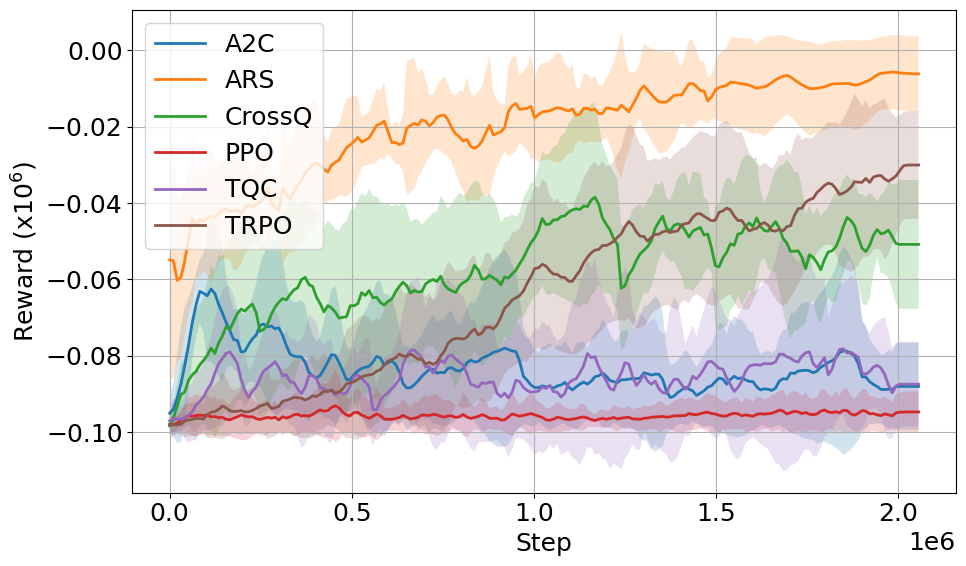

In [6]:
# Define a common x-axis (based on min-max steps across all algorithms)
min_step = df['step'].min()
max_step = df['step'].max()
common_steps = np.linspace(min_step, max_step, 200)

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,6))

# Group by algorithm
for algo, algo_df in df.groupby('algorithm'):
    runs = []

    # For each run (set), interpolate rewards to common steps
    for run_id, run_df in algo_df.groupby('set'):
        x = run_df['step'].values
        y = run_df['reward_scaled'].values
        interp_rewards = np.interp(common_steps, x, y)
        runs.append(interp_rewards)

    runs = np.array(runs)
    mean_rewards = runs.mean(axis=0)
    std_rewards = runs.std(axis=0)

    # Plot with variance shading
    plt.plot(common_steps, mean_rewards, label=algo, linewidth=2)
    plt.fill_between(common_steps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)

plt.xlabel("Step")
plt.ylabel("Reward (x$10^6$)")
# plt.title("RL Algorithms Reward Curves with Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(rf"plots/wheeled_random_{date}.png")
plt.show()

In [7]:
a2c_df = df[df['algorithm']=='A2C']
ppo_df = df[df['algorithm']=='PPO']
trpo_df = df[df['algorithm']=='TRPO']
ars_df = df[df['algorithm']=='ARS']
crossq_df = df[df['algorithm']=='CrossQ']
tqc_df = df[df['algorithm']=='TQC']


a2c_data = {"Setting": "AB", 
            "Algorithm": "A2C", 
            "Mean": a2c_df['reward'].mean(),
            "SD": a2c_df['reward'].std(),
            "Max": a2c_df['reward'].max(),
            "Range": (a2c_df['reward'].max() - a2c_df['reward'].min())}
ppo_data = {"Setting": "AB", 
            "Algorithm": "PPO", 
            "Mean": ppo_df['reward'].mean(),
            "SD": ppo_df['reward'].std(),
            "Max": ppo_df['reward'].max(),
            "Range": (ppo_df['reward'].max() - ppo_df['reward'].min())}
trpo_data = {"Setting": "AB", 
            "Algorithm": "TRPO", 
            "Mean": trpo_df['reward'].mean(),
            "SD": trpo_df['reward'].std(),
            "Max": trpo_df['reward'].max(),
            "Range": (trpo_df['reward'].max() - trpo_df['reward'].min())}
ars_data = {"Setting": "AB", 
            "Algorithm": "ARS", 
            "Mean": ars_df['reward'].mean(),
            "SD": ars_df['reward'].std(),
            "Max": ars_df['reward'].max(),
            "Range": (ars_df['reward'].max() - ars_df['reward'].min())}
crossq_data = {"Setting": "AB", 
            "Algorithm": "CrossQ", 
            "Mean": crossq_df['reward'].mean(),
            "SD": crossq_df['reward'].std(),
            "Max": crossq_df['reward'].max(),
            "Range": (crossq_df['reward'].max() - crossq_df['reward'].min())}
tqc_data = {"Setting": "AB", 
            "Algorithm": "TQC", 
            "Mean": tqc_df['reward'].mean(),
            "SD": tqc_df['reward'].std(),
            "Max": tqc_df['reward'].max(),
            "Range": (tqc_df['reward'].max() - tqc_df['reward'].min())}


set_tab_df = pd.DataFrame([a2c_data, ppo_data, trpo_data, ars_data, crossq_data, tqc_data])
set_tab_df

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-82156.844114,15762.409614,-15861.408203,85116.060547
1,AB,PPO,-94063.706857,5775.931281,-68887.382812,32425.929688
2,AB,TRPO,-60568.365254,28348.916237,-2673.670166,97871.572021
3,AB,ARS,-12290.467383,22145.981017,23931.035156,113659.785156
4,AB,CrossQ,-66581.399184,23974.996117,1014.025696,102047.775696
5,AB,TQC,-89719.714754,14373.440287,-700.285706,104809.065857


In [8]:
set_tab_df_sc = set_tab_df.select_dtypes(include='number') / 1000000
set_tab_df_sc.insert(0, 'Setting', set_tab_df['Setting'])
set_tab_df_sc.insert(1, 'Algorithm', set_tab_df['Algorithm'])
set_tab_df_sc

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-0.082157,0.015762,-0.015861,0.085116
1,AB,PPO,-0.094064,0.005776,-0.068887,0.032426
2,AB,TRPO,-0.060568,0.028349,-0.002674,0.097872
3,AB,ARS,-0.012290,0.022146,0.023931,0.113660
4,AB,CrossQ,-0.066581,0.023975,0.001014,0.102048
5,AB,TQC,-0.089720,0.014373,-0.000700,0.104809


In [9]:
set_tab_df_sc.to_csv(rf"results/wheeled_random_results_{date}.csv")